In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import re
from AgentTorch.substep import SubstepTransition
from AgentTorch.helpers import get_by_path

In [9]:

class KillTUCells(SubstepTransition):
    """
        Transition to kill tumor cells
        Update the state of the tumor cells and remove dead cells from the grid

        Args:
            config (dict): the initial state
            input_variables (dict): input variables
            output_variables (dict): output variables
            arguments (dict): arguments

        Returns:
            state (dict): the updated state
        
        Parameters:
            TUpdeath (float): probability of death
            TUpprol (float): probability of proliferation
            TUintmax (float): maximum capacity of interaction of tumor cells
            TUprolmax (float): maximum capacity of proliferating tumor cells
            Tum_proliferation_status (torch.tensor): proliferation status of tumor cells
            Tum_engagement_status (torch.tensor): engagement status of tumor cells

        Steps:
            1. Feed the input state into the transition function
            2. Get the input variables from the action substep
            3. Get the nature of the transition from comparing random numbers to the probabilities
            4. If the nature is death, remove all tumor cells from 
            the cell grid passed by the action substep (by declaring them zero)
            5. The condition for death is either the random number is less than the probability of death
            or the maximum capacity of interaction or proliferation of tumor cells is less than zero
            6. Return the updated state
            
    """
    def __init__(self, config, input_variables, output_variables, arguments):
        super().__init__(config, input_variables, output_variables, arguments)

    def _get_nature(self, TUpdeath, TUpprol):
        random_numbers = torch.randn(1, 2)
        random_number_proliferate = random_numbers[0, 0]
        random_number_death_migrate = random_numbers[0, 1]

        if random_number_proliferate < TUpprol:
            nature = "proliferate"
        elif random_number_death_migrate < TUpdeath:
            nature = "death"
        else:
            nature = "migrate"
        return nature

    def forward(self, state):
        input_variables = self.input_variables

        # Get the input variables
        TUpdeath = get_by_path(state, re.split("/", input_variables["TUpdeath"]))
        TUpprol = get_by_path(state, re.split("/", input_variables["TUpprol"]))
        TUintmax = get_by_path(state, re.split("/", input_variables["TUintmax"]))
        TUprolmax = get_by_path(state, re.split("/", input_variables["TUprolmax"]))
        Tum_proliferation_status = get_by_path(state, re.split("/", input_variables["Tum_proliferation_status"]))
        Tum_engagement_status = get_by_path(state, re.split("/", input_variables["Tum_engagement_status"]))

        # Rules for killing TU cells, remove from the grid and update the state
        nature = self._get_nature(TUpdeath, TUpprol)

        if nature == 'death' or TUintmax <= 0 or TUprolmax <= 0:
            tumor_cells_id = self.config['agents']['tumorcells']['id']
            state['cell_grid'][tumor_cells_id] = torch.zeros_like(state['cell_grid'][tumor_cells_id])
            TUprolmax[tumor_cells_id] = torch.zeros_like(TUprolmax[tumor_cells_id])
            TUintmax[tumor_cells_id] = torch.zeros_like(TUintmax[tumor_cells_id])
            Tum_proliferation_status[tumor_cells_id] = torch.zeros_like(Tum_proliferation_status[tumor_cells_id])
            Tum_engagement_status[tumor_cells_id] = torch.zeros_like(Tum_engagement_status[tumor_cells_id])

        return state

In [10]:
# Create an instance of killTUCells
config = {
    'agents': {
         'tumorcells': {
                'id': 1,
                'kill_cell_index': torch.tensor([1]),
                'TUpdeath': torch.tensor([0.12], dtype=torch.float32, requires_grad=True),
                'TUprolmax': torch.tensor([10]),
                'TUpprol': torch.tensor([0.5055]),
                'Tum_proliferation_status': torch.tensor([1]),
                'Tum_engagement_status': torch.tensor([0]),
                'TUintmax': torch.tensor([2]),
         }
    },
    'cell_grid': torch.tensor(torch.randn(10, 10)), 
}
input_variables = {
    'kill_cell_index': 'agents/tumorcells/kill_cell_index',
    'TUprolmax': 'agents/tumorcells/TUprolmax',
    'TUpprol': 'agents/tumorcells/TUpprol',
    'Tum_proliferation_status': 'agents/tumorcells/Tum_proliferation_status',
    'Tum_engagement_status': 'agents/tumorcells/Tum_engagement_status',
    'TUintmax': 'agents/tumorcells/TUintmax',
    'TUpdeath': 'agents/tumorcells/TUpdeath',
    'cell_grid': 'agents/tumorcells/cell_grid',
}
output_variables = {} 
arguments = {
    'learnable': {}, 
    'fixed': {}       
}

kill_TU_cells = KillTUCells(config, input_variables, output_variables, arguments)

# Forward pass
output_state = kill_TU_cells(config)

/var/folders/nc/f38nz9pd527gj9dz_9vv58rh0000gn/T/ipykernel_29673/659722886.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'cell_grid': torch.tensor(torch.randn(10, 10)),


In [11]:

print("\nState after Migration:")
print(output_state)
output_state_sum = sum([torch.sum(tensor) for tensor in output_state['agents']['tumorcells'].values() if isinstance(tensor, torch.Tensor)])
print(output_state_sum)



State after Migration:
{'agents': {'tumorcells': {'id': 1, 'kill_cell_index': tensor([1]), 'TUpdeath': tensor([0.1200], requires_grad=True), 'TUprolmax': tensor([10]), 'TUpprol': tensor([0.5055]), 'Tum_proliferation_status': tensor([1]), 'Tum_engagement_status': tensor([0]), 'TUintmax': tensor([2])}}, 'cell_grid': tensor([[-0.2245, -0.8272,  0.0548,  1.0652, -1.1116,  1.4366, -0.7304,  0.0212,
          0.1433,  0.6809],
        [ 0.7695, -0.6008,  0.0588, -1.2630,  0.7469, -0.1623, -0.3597, -0.2442,
          0.8016, -0.7513],
        [ 0.7142, -1.5110, -1.2475,  1.3046,  2.4003,  0.0777, -0.0336, -0.4691,
          2.4434, -0.5869],
        [-0.0290,  0.4497,  0.7384, -1.0651,  0.6184,  1.1703,  3.8211,  0.9285,
         -0.4298, -0.7203],
        [ 0.3720, -1.0340, -0.5027,  0.7067,  0.3057,  0.9115,  0.3378, -0.9532,
          0.1321, -0.7067],
        [ 0.0385, -1.6723, -1.0683, -0.8567,  0.2764, -0.6074, -0.6305,  1.2825,
          0.3087, -0.4725],
        [ 0.1546,  1.0137, -1

In [7]:

loss = output_state_sum
loss.requires_grad
loss.backward()
input_state_sum = sum([torch.sum(tensor) for tensor in config['agents']['tumorcells'].values() if isinstance(tensor, torch.Tensor)])
input_state_sum.requires_grad

True

In [8]:

import torch
import torch.optim as optim
killTUcell = config['agents']['tumorcells']['TUpdeath']
optimizer = optim.SGD([killTUcell], lr=0.01)

In [71]:

grad_values = []

for epoch in range(10):
    # Forward pass
    output_state = kill_TU_cells(config)
    output_state_sum = sum([torch.sum(tensor) for tensor in output_state['agents']['tumorcells'].values() if isinstance(tensor, torch.Tensor)])
    loss = torch.sum(output_state_sum)
    # Backward pass
    loss.backward()
    # Print or plot the gradient values
    print('Gradient of TUpdeath:', killTUcell.grad)
    # Store migrateTUcell.grad values in the list
    grad_values.append(killTUcell.grad.item())
    # Optimize
    optimizer.step()
    # Print or plot the updated migrateTUcell values
    print('Updated TUpdeath:', killTUcell)
    # Print or plot the loss
    print('Loss:', loss.item())
    # Clear gradients for the next iteration
    optimizer.zero_grad()


Gradient of killTUcell: tensor([3.])
Updated killTUcell: tensor([0.0900], requires_grad=True)
Loss: 7.971450328826904
Gradient of killTUcell: tensor([1.])
Updated killTUcell: tensor([0.0800], requires_grad=True)
Loss: 2.5012941360473633
Gradient of killTUcell: tensor([1.])
Updated killTUcell: tensor([0.0700], requires_grad=True)
Loss: 2.4912939071655273
Gradient of killTUcell: tensor([1.])
Updated killTUcell: tensor([0.0600], requires_grad=True)
Loss: 2.4812936782836914
Gradient of killTUcell: tensor([1.])
Updated killTUcell: tensor([0.0500], requires_grad=True)
Loss: 2.4712934494018555
Gradient of killTUcell: tensor([1.])
Updated killTUcell: tensor([0.0400], requires_grad=True)
Loss: 2.461294174194336
Gradient of killTUcell: tensor([1.])
Updated killTUcell: tensor([0.0300], requires_grad=True)
Loss: 2.4512939453125
Gradient of killTUcell: tensor([1.])
Updated killTUcell: tensor([0.0200], requires_grad=True)
Loss: 2.441293716430664
Gradient of killTUcell: tensor([1.])
Updated killTUcel

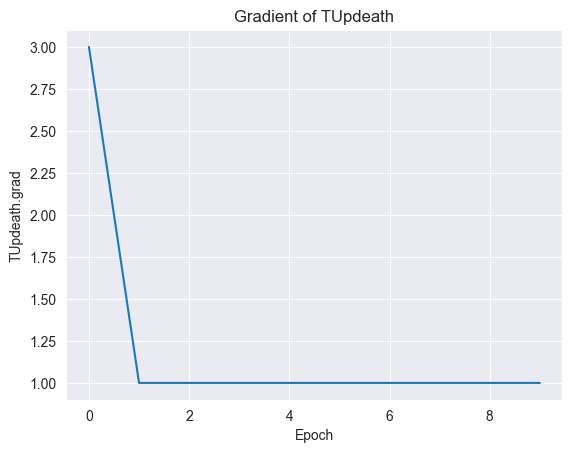

In [73]:

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
plt.plot(grad_values)
plt.xlabel('Epoch')
plt.ylabel('TUpdeath.grad')
plt.title('Gradient of TUpdeath')
plt.show()